In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
)

sns.set_theme(style="whitegrid", palette="Set2")

%matplotlib inline

In [21]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")


X_train = X_train.loc[:, ~X_train.columns.str.contains("^Unnamed")]
X_test = X_test.loc[:, ~X_test.columns.str.contains("^Unnamed")]


if isinstance(y_train, pd.DataFrame):
    y_train = y_train.loc[:, ~y_train.columns.str.contains("^Unnamed")].iloc[:, 0]
    
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.loc[:, ~y_test.columns.str.contains("^Unnamed")].iloc[:, 0]
    
    
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True).round(3))
print("y_test distribution:\n", y_test.value_counts(normalize=True).round(3))

X_train: (1200, 32)
X_test : (300, 32)
y_train distribution:
 target_bin
1    0.793
0    0.207
Name: proportion, dtype: float64
y_test distribution:
 target_bin
1    0.793
0    0.207
Name: proportion, dtype: float64


In [22]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced", n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}

In [23]:
results = []
fitted_models = {}


for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    
    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
    }
    
    
    if y_proba is not None:
        row["roc_auc"] = roc_auc_score(y_test, y_proba)
        row["pr_score"] = average_precision_score(y_test, y_proba)
    else:
        row["roc_auc"] = None
        row["pr_score"] = None
        
        
    results.append(row)
    
results_df = pd.DataFrame(results)
display(results_df)
    

,model,accuracy,precision,recall,f1_score,roc_auc,pr_score
0,LogisticRegression,1.0,1.0,1.0,1.0,1.0,1.0
1,RandomForest,1.0,1.0,1.0,1.0,1.0,1.0
2,GradientBoosting,1.0,1.0,1.0,1.0,1.0,1.0


There is no way this is 1.000, the data is synthetic or either my code is not good. there might be data leaks but a high chance the data is so good that it can reach 1.0, which means its not real.

,model,accuracy,precision,recall,f1_score,roc_auc,pr_score
0,LogisticRegression,1.0,1.0,1.0,1.0,1.0,1.0
1,RandomForest,1.0,1.0,1.0,1.0,1.0,1.0
2,GradientBoosting,1.0,1.0,1.0,1.0,1.0,1.0


Best baseline Model: LogisticRegression


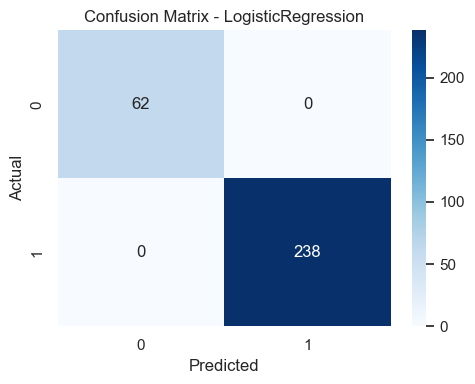

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        62
           1     1.0000    1.0000    1.0000       238

    accuracy                         1.0000       300
   macro avg     1.0000    1.0000    1.0000       300
weighted avg     1.0000    1.0000    1.0000       300



In [24]:
results_df = results_df.sort_values(by=['recall', 'f1_score', 'roc_auc'], ascending=False).reset_index(drop=True)
display(results_df)
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]

print(f"Best baseline Model: {best_model_name}")


y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
print(classification_report(y_test, y_pred_best, digits=4))

In [25]:
# if hasattr(best_model, "predict_proba"):
#     y_proba_best = best_model.predict_proba(X_test)[:, 1]
    
#     fig, ax = plt.subplots(1,2, figsize=(12, 5))
#     RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=ax[0], name=best_model_name)
#     PrecisionRecallDisplay.from_predictions(y_test, y_proba_best, ax=ax[1], name=best_model_name)
#     ax[0].set_title(f"ROC Curve - {best_model_name}")
#     ax[1].set_title(f"Precision-Recall Curve - {best_model_name}")
#     plt.tight_layout()
#     plt.show()

comparison_rows = []

for name, model in fitted_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    row = {
        "model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "specificity": tn / (tn + fp) if (tn + fp) else 0,
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
        "pr_auc": average_precision_score(y_test, y_proba) if y_proba is not None else np.nan
    }
    
    comparison_rows.append(row)
comparison_df = pd.DataFrame(comparison_rows).sort_values(by=['recall', 'f1_score', 'accuracy'], ascending=False)
display(comparison_df)

# this are not needed the model has small amount of comparison just look at the table
# comparison_df_plot = comparison_df.set_index("model")[["recall", "precision", "f1_score", "roc_auc", "pr_auc"]]
# comparison_df_plot.plot(kind="bar", figsize=(10, 6), colormap="Set2")
# plt.title("Model Performance Comparison")
# plt.ylabel("Score")
# plt.tight_layout()
# plt.show()

,model,TN,FP,FN,TP,specificity,precision,recall,f1_score,accuracy,roc_auc,pr_auc
0,LogisticRegression,62,0,0,238,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,RandomForest,62,0,0,238,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,GradientBoosting,62,0,0,238,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [26]:
if hasattr(best_model, "predict_proba"):
    y_proba_best = best_model.predict_proba(X_test)[:, 1]
    
    thresholds = np.arange(0.10, 0.91, 0.05)
    th_rows = []
    
    for t in thresholds:
        y_pred_th = (y_proba_best >= t).astype(int)
        th_rows.append({
            "threshold": t,
            "accuracy": accuracy_score(y_test, y_pred_th),
            "precision": precision_score(y_test, y_pred_th, zero_division=0),
            "recall": recall_score(y_test, y_pred_th, zero_division=0),
            "f1_score": f1_score(y_test, y_pred_th, zero_division=0)
        })
    thresholds_df = pd.DataFrame(th_rows)
    
    display(thresholds_df)
    

,threshold,accuracy,precision,recall,f1_score
0,0.10,0.993333,0.991667,1.000000,0.995816
1,0.15,1.000000,1.000000,1.000000,1.000000
2,0.20,1.000000,1.000000,1.000000,1.000000
3,0.25,1.000000,1.000000,1.000000,1.000000
4,0.30,1.000000,1.000000,1.000000,1.000000
5,0.35,1.000000,1.000000,1.000000,1.000000
6,0.40,1.000000,1.000000,1.000000,1.000000
7,0.45,1.000000,1.000000,1.000000,1.000000
8,0.50,1.000000,1.000000,1.000000,1.000000
9,0.55,1.000000,1.000000,1.000000,1.000000


In [27]:
import os
os.makedirs("../reports", exist_ok=True)

results_df.to_csv("../reports/baseline_model_comparison.csv", index=False)
print("Saved baseline comparison to ../reports/baseline_model_comparison.csv")

Saved baseline comparison to ../reports/baseline_model_comparison.csv


In [28]:
from sklearn.model_selection import StratifiedKFold, cross_validate


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1_score": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_rows = []

for name, model in models.items():
    cv_out = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    cv_rows.append({
        "model": name,
        "cv_accuracy_mean": cv_out["test_accuracy"].mean(),
        "cv_precision_mean": cv_out["test_precision"].mean(),
        "cv_recall_mean": cv_out["test_recall"].mean(),
        "cv_f1_mean": cv_out["test_f1_score"].mean(),
        "cv_roc_auc_mean": cv_out["test_roc_auc"].mean(),
        "cv_pr_auc_mean": cv_out["test_pr_auc"].mean()
    })
    
cv_df = pd.DataFrame(cv_rows).sort_values(by=["cv_recall_mean", "cv_f1_mean", "cv_roc_auc_mean", "cv_pr_auc_mean" ], ascending=False)
display(cv_df.round(4))

,model,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,cv_pr_auc_mean
1,RandomForest,0.9967,0.9958,1.0000,0.9979,0.9999,1.0000
2,GradientBoosting,0.9933,0.9928,0.9989,0.9958,0.9997,0.9999
0,LogisticRegression,0.9967,0.9979,0.9979,0.9979,0.9999,1.0000


In [35]:
import glob
import os
import sys
import pandas as pd

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.predict import load_model, load_feature_columns, align_features, predict_labels, predict_proba

model_files = sorted(glob.glob("../models/*.joblib"))
col_files = sorted(glob.glob("../models/feature_columns_*.json"))

if not model_files or not col_files:
    raise FileNotFoundError(
        "No saved model artifacts found in ../models/. "
        "Run your training pipeline first to generate .joblib and feature_columns_*.json files."
    )

latest_model = model_files[-1]
latest_cols = col_files[-1]

model = load_model(latest_model)
train_cols = load_feature_columns(latest_cols)

sample = pd.read_csv("../data/processed/X_test.csv")
sample = sample.loc[:, ~sample.columns.str.contains("^Unnamed")].head(5)
sample = align_features(sample, train_cols)

print("Using model:", latest_model)
print("Using feature schema:", latest_cols)
print("Predicted labels:", predict_labels(model, sample))
print("Predicted probabilities:", predict_proba(model, sample))

Using model: ../models\best_model_20260320_133956.joblib
Using feature schema: ../models\feature_columns_20260320_133956.json
Predicted labels: [0 0 0 0 0]
Predicted probabilities: [0.00333333 0.00333333 0.00333333 0.00333333 0.00333333]


In [36]:
print("train_cols count:", len(train_cols))
print("sample original cols:", sample.shape[1])

common = [c for c in sample.columns if c in train_cols]
print("overlap count:", len(common))
print("first overlaps:", common[:10])

aligned = align_features(sample, train_cols)
print("aligned shape:", aligned.shape)
print("row sums:", aligned.sum(axis=1).tolist())

train_cols count: 45
sample original cols: 45
overlap count: 45
first overlaps: ['Age', 'BMI', 'Is_Pregnant', 'Duration_of_Symptoms_Hours', 'Pain_Migration', 'Nausea_Vomiting', 'Loss_of_Appetite', 'Fever_Temp_C', 'Rebound_Tenderness', 'McBurney_Sign']
aligned shape: (5, 45)
row sums: [0, 0, 0, 0, 0]


In [37]:
from src.data_prep import load_raw_data, clean_data
from src.features import engineer_features, to_model_matrix

df_raw = load_raw_data("../data/raw/appendicitis_comprehensive_dataset.csv")
df_clean = clean_data(df_raw)
df_feat = engineer_features(df_clean)
X_all, y_all = to_model_matrix(df_feat)

sample = X_all.head(5)
sample = align_features(sample, train_cols)

print("Predicted labels:", predict_labels(model, sample))
print("Predicted probabilities:", predict_proba(model, sample))

Predicted labels: [1 1 1 1 0]
Predicted probabilities: [1.         0.99333333 1.         1.         0.        ]


In [38]:

import glob
import os
import sys
import pandas as pd

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.predict import (
    load_model,
    load_feature_columns,
    align_features,
    predict_labels,
    predict_proba,
)
from src.data_prep import load_raw_data, clean_data
from src.features import engineer_features, to_model_matrix

# Find latest saved artifacts
model_files = sorted(glob.glob("../models/*.joblib"))
col_files = sorted(glob.glob("../models/feature_columns_*.json"))

if not model_files or not col_files:
    raise FileNotFoundError(
        "No saved model artifacts found in ../models/. "
        "Run: python -m src.main_pipeline"
    )

latest_model = model_files[-1]
latest_cols = col_files[-1]

# Load model + feature schema
model = load_model(latest_model)
train_cols = load_feature_columns(latest_cols)

# Build inference features using SAME path as training
df_raw = load_raw_data("../data/raw/appendicitis_comprehensive_dataset.csv")
df_clean = clean_data(df_raw)
df_feat = engineer_features(df_clean)
X_all, y_all = to_model_matrix(df_feat)

# pick sample rows
sample_infer = X_all.head(5)

#  Align columns to training schema
sample_aligned = align_features(sample_infer, train_cols)

# Predict
labels = predict_labels(model, sample_aligned)
probas = predict_proba(model, sample_aligned)

# Sanity checks + output
print("Using model:", latest_model)
print("Using feature schema:", latest_cols)
print("train_cols count:", len(train_cols))
print("sample_aligned shape:", sample_aligned.shape)
print("row sums:", sample_aligned.sum(axis=1).tolist())
print("Predicted labels:", labels)
print("Predicted probabilities:", probas)

Using model: ../models\best_model_20260320_133956.joblib
Using feature schema: ../models\feature_columns_20260320_133956.json
train_cols count: 45
sample_aligned shape: (5, 45)
row sums: [306.20000000000005, 311.98, 380.48999999999995, 286.5, 230.88]
Predicted labels: [1 1 1 1 0]
Predicted probabilities: [1.         0.99333333 1.         1.         0.        ]
